**Procesamiento de Imágenes - ITSE - Instituto Tecnológico de Santiago del Estero**

**Alumno: Claramunt Federico**

# Introduction Example for Image Processing

Rice Segmentation

# Input Image

In [1]:
import urllib.request

def descargar(url, nombre):
    urllib.request.urlretrieve(url, nombre)
    print(f'OK -> {nombre}')

REPO = 'https://raw.githubusercontent.com/domingomery/pr/main/clases/'
descargar(REPO + 'PR01_Introduccion/datos/onerice.bmp', 'onerice.bmp')

OK -> onerice.bmp


# Libraries

In [2]:
import numpy as np
from cv2 import imread
import matplotlib.pyplot as plt

# Read and display the image

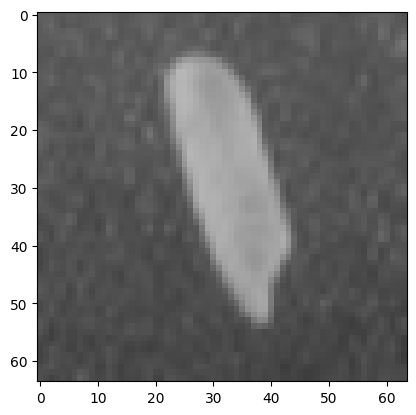

In [3]:
img = imread('onerice.bmp')
plt.imshow(img)
plt.show()

# How is the image?

In [4]:
def howis(img):
  print('size = ',img.shape)
  print('max  = ',np.max(img))
  print('min  = ',np.min(img))

howis(img)

size =  (64, 64, 3)
max  =  183
min  =  59


# Selection of first channel (RED)

size =  (64, 64)
max  =  183
min  =  59


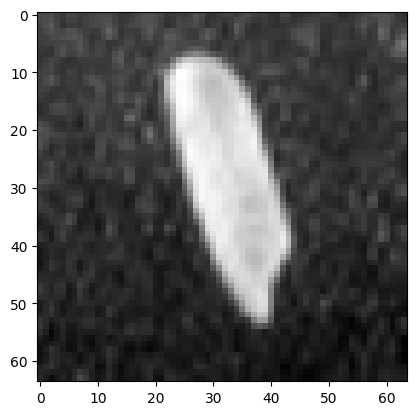

In [5]:
X = img[:,:,0]
howis(X)
plt.imshow(X,cmap='gray')
plt.show()

# Thresholding - Simple Segmentation

In [6]:
def segmenta(X,t):
  (N,M) = X.shape
  Y = np.zeros((N,M))
  area = 0
  for i in range(N):
    for j in range(M):
      if X[i,j] > t:
        Y[i,j] = 255
        area = area + 1
  print('area = ',area)
  return Y

# Segmentation

area =  597
size =  (64, 64)
max  =  255.0
min  =  0.0


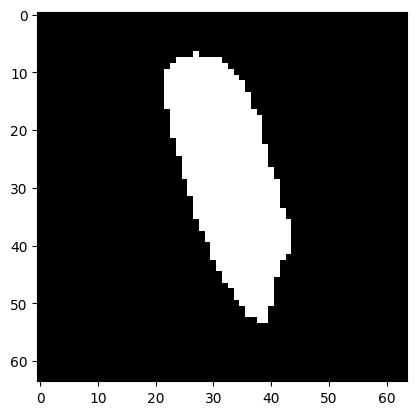

In [7]:
Y = segmenta(X,120) # good threshold is 120
howis(Y)
plt.imshow(Y,cmap='gray')
plt.show()

# More rices: a little bit complicated...

In [8]:
descargar(REPO + 'PR01_Introduccion/datos/rices.png', 'rices.png')

OK -> rices.png


size =  (512, 512)
max  =  207
min  =  38


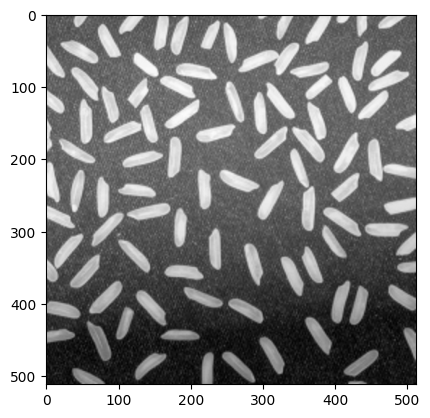

In [9]:
img = imread('rices.png')
X   = img[:,:,0]
howis(X)
plt.imshow(X,cmap='gray')
plt.show()

A global threshold does not work! why?

Test with 90, 110, 130 y 150

area =  97141


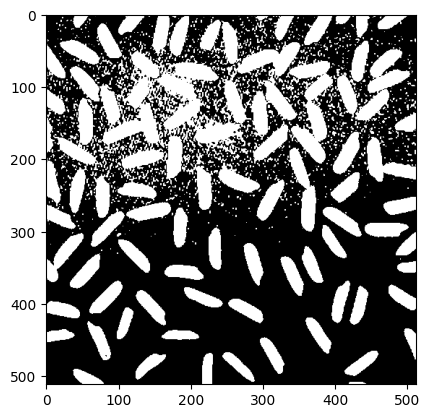

In [10]:
Y = segmenta(X,110)
plt.imshow(Y,cmap='gray')
plt.show()

# Definition of a homogeneous background

Each row is the original row minus its minimum

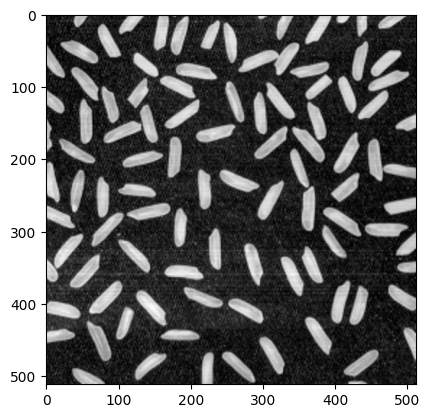

In [11]:
(N,M) = X.shape
Xm    = np.zeros((N,M),np.uint8)
for i in range(N):
  xmin = np.min(X[i,:])
  Xm[i,:] = X[i,:] - xmin
plt.imshow(Xm,cmap='gray')
plt.show()

area =  68445


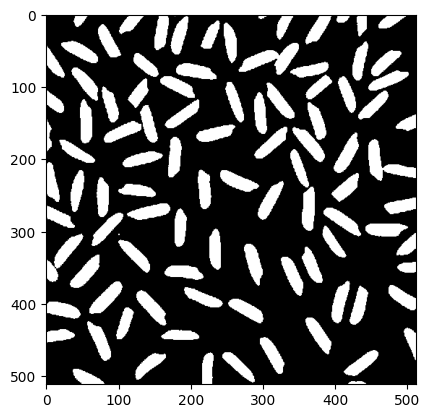

In [12]:
Y = segmenta(Xm,60)
plt.imshow(Y,cmap='gray')
plt.show()

# Cuestionario

**Resuelto por: Claramunt Federico**

## Pregunta 1 — Verdadero o Falso

**El procesamiento de imágenes utiliza algoritmos computacionales que toman una imagen como entrada y entregan una imagen como salida.**

**Respuesta: Verdadero (V)**  
El procesamiento de imágenes recibe una imagen de entrada y entrega una imagen de salida. Es el caso de la segmentación: la imagen del arroz entra y se obtiene una imagen binaria segmentada.

## Pregunta 2 — Verdadero o Falso

**En el análisis de imágenes, el resultado necesariamente debe ser otra imagen.**

**Respuesta: Falso (F)**  
En el análisis de imágenes el resultado NO tiene que ser otra imagen: puede ser una medición, interpretación o decisión (por ejemplo, el área del grano de arroz calculada tras la segmentación).

## Pregunta 3 — Opción múltiple

**¿Cuál de las siguientes opciones corresponde al objetivo del análisis de imágenes?**

A) Generar únicamente imágenes 3D.  
B) Obtener una medición, interpretación o decisión a partir de una imagen.  
C) Convertir siempre una imagen en otra imagen.  
D) Eliminar todos los píxeles de una imagen.

**Respuesta: B) Obtener una medición, interpretación o decisión a partir de una imagen.**

## Pregunta 4 — Verdadero o Falso

**El reconocimiento de patrones utiliza métodos que hacen inferencia a partir de datos y puede asignar un objeto a una clase.**

- V = Verdadero
- F = Falso

**Respuesta: Verdadero (V)**  
El reconocimiento de patrones infiere a partir de datos y puede asignar cada objeto a una clase (por ejemplo, clasificar un grano como arroz o no arroz).

## Pregunta 5 — Opción múltiple

**En el ejemplo de análisis de una imagen de arroz, ¿cuál es una de las tareas planteadas?**

A) Calcular la temperatura del arroz.  
B) Segmentar el grano de arroz.  
C) Generar una malla 3D del arroz.  
D) Clasificar el arroz por variedad genética.

**Respuesta: B) Segmentar el grano de arroz.**  
En el notebook se segmenta el grano de arroz mediante umbralización (`segmenta(X, 120)`).

## Pregunta 6 — Opción múltiple

**En el ejemplo del arroz, ¿cómo se calcula el área después de la segmentación?**

A) Sumando los valores de intensidad de todos los píxeles.  
B) Contando cuántos píxeles son mayores que 170.  
C) Calculando el promedio de todos los píxeles.  
D) Multiplicando el ancho por la altura de la imagen.

**Respuesta: B) Contando cuántos píxeles son mayores que 170.**  
El área se calcula contando los píxeles cuyo valor supera el umbral (`if X[i,j] > t`). En el ejemplo del notebook el umbral fue 120 y el área resultante fue **597** píxeles.

## Pregunta 7 — Opción múltiple

**¿Cuál de las siguientes secuencias representa el flujo mostrado para el análisis de una imagen?**

A) Adquisición → Preprocesamiento → Segmentación → Extracción de características → Clasificación.  
B) Clasificación → Adquisición → Segmentación → Preprocesamiento.  
C) Segmentación → Clasificación → Adquisición → Extracción de características.  
D) Preprocesamiento → Clasificación → Adquisición → Segmentación.

**Respuesta: A) Adquisición → Preprocesamiento → Segmentación → Extracción de características → Clasificación.**  
Es el orden lógico del pipeline de análisis de imágenes visto en la presentación.

## Pregunta 8 — Verdadero o Falso

**La computación gráfica se presenta como el uso de algoritmos computacionales para generar imágenes a partir de modelos, incluyendo objetos 3D, textura, color e iluminación.**

- V = Verdadero
- F = Falso

**Respuesta: Verdadero (V)**  
La computación gráfica genera imágenes a partir de modelos (objetos 3D, textura, color, iluminación).

## Pregunta 9 — Opción múltiple

**¿Cuál de estas afirmaciones describe mejor la visión por computador según la presentación?**

A) Es únicamente una técnica para comprimir imágenes.  
B) Es la ciencia que proporciona a los computadores la capacidad de 'ver'.  
C) Es un método exclusivo para crear modelos 3D.  
D) Es una técnica para aumentar la resolución de las imágenes.

**Respuesta: B) Es la ciencia que proporciona a los computadores la capacidad de 'ver'.**

## Pregunta 10 — Opción múltiple

**¿Cuál de estas afirmaciones describe mejor la visión por computador según la presentación?**

A) Es únicamente una técnica para comprimir imágenes.  
B) Es la ciencia que proporciona a los computadores la capacidad de 'ver'.  
C) Es un método exclusivo para crear modelos 3D.  
D) Es una técnica para aumentar la resolución de las imágenes.

**Respuesta: B) Es la ciencia que proporciona a los computadores la capacidad de 'ver'.**  
Nota: esta pregunta es una repetición de la Pregunta 9, por lo que la respuesta es la misma.

**Bibliografía**  
D. Mery. Fundamentos de Procesamiento de Imágenes Departamento de Ciencia de la Computación. Universidad Católica de Chile, 2024.